# Dataset Explore `10-31-2025`

In [1]:
from datasets import load_dataset
from tqdm.notebook import tqdm

In [2]:
# dataset = load_dataset('json', data_files='PyranetStatisticData/dataset_all_with_cell_num_error.jsonl', split = "train")
dataset = load_dataset('bnadimi/PyraNet-Verilog', split = "train")

In [ ]:
dataset.to_json('bnadimi_PyraNet-fixed_code_only.jsonl')

In [4]:
dataset

Dataset({
    features: ['code', 'description'],
    num_rows: 692238
})

In [3]:
from module_extraction import module_extraction

import json, re, tempfile, subprocess, os, signal
import numpy as np

alpaca_prompt = """Below is an instruction that describes a task, paired with an input that provides further context. Write a response that appropriately completes the request.

### Instruction:
{}

### Input:
{}

### Response:
{}"""

def formatting_prompts_func(examples):
    example_descriptions = examples["description"]
    example_module_codes = examples["code"]
    
    # example_module_definitions = []
    example_module_def_spans = []
    for example_description, example_code in zip(example_descriptions, example_module_codes):
        # format, for \n placements
        # example_code = example_code.replace("\\\\", "\\")
        # print(example_description)
        example_description = example_description.replace("\\\\", "\\")
        example_description_dict = json.loads(example_description)

        # trial_result = 0

        # while True:
        #     # signal.alarm(3)
        #     try:
        [module_definitions, module_output_codes, module_definitions_with_comments, module_def_spans] = module_extraction(example_code)
                # trial_result = 2
                # [module_definitions, module_output_codes, _] = module_extraction(example_code)
            # except:
            #     trial_result += 1
            #     print("Try fixing...")
            #     example_code = "/* <fixed_COMBA>" + example_code
                # signal.alarm(3)
                # [module_definitions, module_output_codes, module_definitions_with_comments] = module_extraction(example_code)
            # timeout_ex.add(i)
            # signal.alarm(0)
            # if trial_result > 1:
            #     break
        example_module_def_spans.append(module_def_spans)
        # example_fix_codes.append(example_code)
        # example_instructions.append(example_description_dict['description'])
        # example_module_definitions.append(module_definitions)
    #     instruction  = example_instruction + "\nBased on the below guidance from module definitions, write appropriate Verilog code to complete the request."
    #     module_def   = '\n'.join(example_module_definition_with_comment)
    #     output       = module_wrapper
    #     text = alpaca_prompt.format(instruction, module_def, output) + EOS_TOKEN
    #     texts.append(text)
    # return { "text": texts, }
    return {
        # "instruction": example_instructions,
            # "module_definition": example_module_definitions,
            # "fixed_code": example_fix_codes
            "module_def_span": example_module_def_spans
           }
pass

dataset = dataset.map(formatting_prompts_func, batched = True, num_proc=os.cpu_count())

In [3]:
dataset

Dataset({
    features: ['description', 'code', 'module_definition', 'module_def_span', 'synth_status'],
    num_rows: 661318
})

# Explore modules synthesys

In [3]:
from tqdm.notebook import tqdm

In [ ]:
import subprocess
pbar = tqdm(total=len(dataset))
synth_error_ex = set()
for i in range(len(dataset)):
    example_code = dataset['code'][i]

    with open('yosys_run/top.v', 'w+') as file:
        file.write(example_code)
    runresult = subprocess.run(['./run.sh'],
                               cwd='yosys_run',
                               capture_output=True,
                               text=True
                               # stdin=subprocess.STDOUT,
                               # stderr=subprocess.STDOUT
                              )
    if runresult.returncode:
        # print(runresult.stdout)
        # print(runresult.stderr)
        # break
        synth_error_ex.add(i)
    pbar.update(1)

In [8]:
import os
os.cpu_count()

24

In [4]:
import subprocess, tempfile, json, signal, os

dlatch_err = "ERROR: Latch inferred for signal"

def do_process(i):#process_range, synth_error_ex):
    # print(i)
    # pbar.update(1)
    # for i in process_range:
    example_code = dataset['code'][i]
    # print(example_code)
    # return
    total_num_cells = 0
    with tempfile.TemporaryDirectory() as tmpdirname:
        os.link('yosys_run/run3.sh', f'{tmpdirname}/run.sh')
        with open(f'{tmpdirname}/top.v', 'w+') as file:
            file.write(example_code)
        try:
            runresult = subprocess.Popen('systemd-run --scope -p MemoryMax=2G --user ./run.sh',
                                         cwd=tmpdirname,
                                        stdout=subprocess.DEVNULL,
                                         stderr=subprocess.DEVNULL,
                                         # stdout=subprocess.PIPE,
                                         # stderr=subprocess.PIPE,
                                           shell=True, 
                                         preexec_fn=os.setsid,
                                        )
            # runresult = subprocess.Popen('./run.sh',
            #                             # ['./run.sh'], 
            #                              cwd=tmpdirname,
            #                              shell=True,
            #                             stdout=subprocess.DEVNULL,
            #                              stderr=subprocess.DEVNULL)
            runresult.wait(300)
            # runresult.wait(timeout)
            if runresult.returncode != 0:
                # stdout_str = runresult.stdout.read().decode('utf-8')
                # if dlatch_err in stdout_str:
                #     print(i, stdout_str)
                # print(runresult.stderr.readlines())
                
                return (i, 0, None)
            else:
                with open(f'{tmpdirname}/out.json', 'r') as file:
                    module_synthesis = json.load(file)
                    for module in module_synthesis['modules']:
                        total_num_cells += module_synthesis['modules'][module]['num_cells']
                    
                return (i, 0, total_num_cells)
        except subprocess.TimeoutExpired:
            os.killpg(os.getpgid(runresult.pid), signal.SIGTERM)
            return (i, 1, None)
            
        # synth_error_ex.add(i)
    # pbar.update(1)

In [ ]:
from multiprocessing.managers import BaseManager
from multiprocess import Pool
import subprocess

import os
num_core = os.cpu_count() - 4
my_range = range(len(dataset))

synth_error_ex = set()
synth_timeout_ex = set()
all_total_num_cells = [None] * (my_range[-1] + 1)
os.makedirs('.cache_count_num_cell', exist_ok=True)
with Pool(processes=num_core) as pool:
    for i in tqdm(iterable=pool.imap_unordered(do_process, my_range), total=len(my_range)):
        ii, timeout, total_num_cells = i
        with open(f'.cache_count_num_cell/{ii}.txt', 'w+') as file:
            file.write(','.join([str(x) for x in i[1:]]))
        if timeout:
            synth_timeout_ex.add(ii)
        elif total_num_cells != None:
            all_total_num_cells[ii] = total_num_cells
        else:
            synth_error_ex.add(ii)
# print(all_total_num_cells)

  0%|          | 0/692238 [00:00<?, ?it/s]

In [ ]:
all_total_num_cells

In [7]:
import json
with open('PyranetStatisticData/all_num_cells.json', 'r') as file:
    all_total_num_cells = json.load(file)

In [ ]:
all_total_num_cells

In [7]:
import json
with open('PyranetStatisticData/all_num_cells.json', 'w+') as file:
    json.dump(all_total_num_cells, file)

In [21]:
import numpy as np
all_num_cells_with_error = np.full((len(all_total_num_cells), 2), None)
all_num_cells_with_error

array([[None, None],
       [None, None],
       [None, None],
       ...,
       [None, None],
       [None, None],
       [None, None]], shape=(661318, 2), dtype=object)

In [22]:
all_num_cells_with_error[:,0] = all_total_num_cells
all_num_cells_with_error

array([[0, None],
       [2, None],
       [16, None],
       ...,
       [None, None],
       [None, None],
       [None, None]], shape=(661318, 2), dtype=object)

In [24]:
all_num_cells_with_error[list(synth_timeout_ex),1] = 2
all_num_cells_with_error

array([[0, None],
       [2, None],
       [16, None],
       ...,
       [None, 1],
       [None, 1],
       [None, 1]], shape=(661318, 2), dtype=object)

In [24]:
str(all_num_cells_with_error[0])

'[0 None]'

In [19]:
len(synth_error_ex)

305429

In [20]:
len(synth_timeout_ex) # old V0

1061

In [35]:
idxs = np.where(all_num_cells_with_error[:, 0] != None)
np.max(all_num_cells_with_error[idxs, 0])

1308809

In [25]:
with open('PyranetStatisticData/all_num_cells_with_error_2GB_5m.jsonl', 'w+') as file:
    json.dump(all_num_cells_with_error.tolist(), file)

In [28]:
dataset = dataset.remove_columns(['synth_status'])

In [29]:
dataset

Dataset({
    features: ['description', 'code', 'module_definition', 'module_def_span'],
    num_rows: 661318
})

In [31]:
dataset = dataset.add_column("num_cell", all_num_cells_with_error[:,0])

In [32]:
dataset

Dataset({
    features: ['description', 'code', 'module_definition', 'module_def_span', 'synth_status', 'num_cell'],
    num_rows: 661318
})

In [33]:
dataset.to_json('PyranetStatisticData/dataset_all_with_cell_num_error_timeout.jsonl')

Creating json from Arrow format:   0%|          | 0/662 [00:00<?, ?ba/s]

2536495589

In [ ]:
(np.min(all_num_cells_with_error[:,0]), np.max(all_num_cells_with_error[:,0]))

In [33]:
# all_valid_num_cells = np.where(all_num_cells_with_error[:,0] != None, all_num_cells_with_error[:,0], all_num_cells_with_error[:,0])
# all_valid_num_cells
all_valid_num_cells = np.where(all_num_cells_with_error[:,0] != None)

In [36]:
all_valid_num_cells = all_num_cells_with_error[all_valid_num_cells,0]
all_valid_num_cells

array([[0, 2, 16, ..., 322, 3, 0]], shape=(1, 351429), dtype=object)

In [37]:
np.max(all_valid_num_cells)

217596

In [77]:
max([i for i in all_total_num_cells if i != None])

108837

In [ ]:
pbar = tqdm(total=len(dataset))
# synth_error_ex = set()
for i in range(len(dataset)):
    ret_val = do_process(i)
    # if ret_val != None:
    #     synth_error_ex.add(i)
    pbar.update(1)
pbar.close()
# 1283

In [ ]:
print(dataset['code'][897])

In [ ]:
pbar.close()

In [ ]:
from multiprocessing import Process
import os
num_core = os.cpu_count() - 1
processes = [None] * num_core
process_ranges = range(len(dataset))
range_slice_step = int(len(process_ranges) / num_core) + 1
for i in range(num_core):
    range_slice_start = range_slice_step * i
    # if i == num_core - 1:
    #     range_slice_end = None
    # else:
    range_slice_end = range_slice_start + 1 #range_slice_step - 1
    cur_range = process_ranges[range_slice_start:range_slice_end]
    # print(cur_range)
    processes[i] = Process(target=do_process, args=(cur_range, synth_error_ex))
    processes[i].start()
for i in range(num_core):
    processes[i].join()

In [ ]:
pbar.close()

In [ ]:
runresult.stdout

In [ ]:
i

# Explore Logic Numbers

In [4]:
import numpy as np

all_cell_num_with_no_null = np.array(dataset['synth_status'])
all_cell_num_with_no_null

array([0.0, 2.0, 16.0, ..., None, None, None],
      shape=(661318,), dtype=object)

In [5]:
all_cell_num_with_no_null_idx = np.where(all_cell_num_with_no_null != None)
all_cell_num_with_no_null_idx

(array([     0,      1,      2, ..., 661292, 661309, 661311],
       shape=(351429,)),)

In [6]:
all_cell_num_with_no_null = all_cell_num_with_no_null[all_cell_num_with_no_null_idx]
all_cell_num_with_no_null

array([0.0, 2.0, 16.0, ..., 322.0, 3.0, 0.0],
      shape=(351429,), dtype=object)

In [7]:
all_cell_num_with_no_null = all_cell_num_with_no_null.astype(np.uint64) 
all_cell_num_with_no_null

array([  0,   2,  16, ..., 322,   3,   0], shape=(351429,), dtype=uint64)

In [8]:
np.max(all_cell_num_with_no_null)

np.uint64(217596)

## All Logic num

In [ ]:
set(all_cell_num_with_no_null)

In [28]:
len(np.where(all_cell_num_with_no_null == 0)[0])

42468

In [9]:
logic_num_group = {str(logic_num): len(np.where(all_cell_num_with_no_null == logic_num)[0]) for logic_num in set(all_cell_num_with_no_null)}
len(logic_num_group)

12169

In [ ]:
logic_num_group = {'num_cell': logic_num_group.keys(),
                  'num_module': [logic_num_group[key] for key in logic_num_group]}
logic_num_group

In [11]:
list(logic_num_group.keys())[:100]

['num_cell', 'num_module']

In [12]:
logic_num_group['num_cell'] = list(logic_num_group['num_cell'])

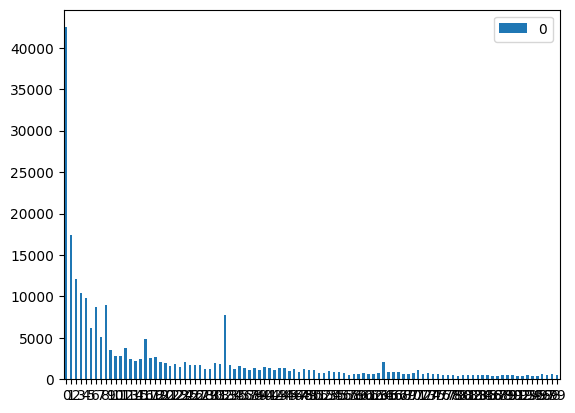

In [18]:
import pandas as pd
logic_num_group_0 = {'num_cell': logic_num_group['num_cell'][:100],
                  'num_module': logic_num_group['num_module'][:100]}
df = pd.DataFrame(logic_num_group_0['num_module'], index=logic_num_group_0['num_cell'])
# ax = df.plot.bar(x='num_cell', y='num_module', rot=0)
ax = df.plot.bar(rot=0)

In [19]:
def num_cell_segment(x):
    int_x = int(x)
    group = ''
    if x == 0:
        group = '0-0'
    else:
        for i in range(1,92, 10):
            cur_range = (i, i + 9)
            if cur_range[0] <= int_x <= cur_range[1]:
                group = f'{cur_range[0]}-{cur_range[1]}'
                break
    # print(x)
    return group
        
df_group = df.groupby(num_cell_segment, ).sum() #.rename(columns={0: 'Number of Cells'}).ren.plot.bar(rot=45,)

In [20]:
df_group = df_group.rename(index={'': '0'}).rename(columns={0: 'Number of Modules'})
df_group

,Number of Cells
0,42468
1-10,85218
11-20,27726
21-30,16752
31-40,20756
41-50,11568
51-60,7505
61-70,8587
71-80,6418
81-90,4737


In [39]:
plt.savefig('PyranetStatisticData/first_plot.pdf', format='pdf')
plt.close()

In [41]:
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
with PdfPages('PyranetStatisticData/first_plot.pdf') as pdf:
    plt.figure()
    # plt.bar(df_group.index, df_group['Number of Cells'])
    df_group.plot.bar(rot=45, )
    pdf.savefig()  # Save the first plot
    plt.close()    # Close the figure to free up memory


<Figure size 640x480 with 0 Axes>

# Explore instantiation number

min_ins_num = [len(dataset['module_definition'][0]), 0]
max_ins_num = [len(dataset['module_definition'][0]), 0]
len_dict = {}
for i in range(1, len(dataset)):
    len_module_definition = len(dataset['module_definition'][i])
    if len_module_definition < min_ins_num[0]:
        min_ins_num[0] = len_module_definition
    if len_module_definition > max_ins_num[0]:
        max_ins_num[0] = len_module_definition

    len_module_definition = str(len_module_definition)
    if len_module_definition not in len_dict:
        len_dict[len_module_definition] = []
    len_dict[len_module_definition].append(i)
    
(min_ins_num, max_ins_num)

In [ ]:
len(len_dict)

In [ ]:
lens = [int(x) for x in list(len_dict.keys())]

In [ ]:
lens.sort()
lens

In [ ]:
import json
with open('PyranetStatisticData/num_ins_dictionary.json', 'w+') as file:
    json.dump(len_dict, file)


In [ ]:
print(dataset['code'][111111])

In [ ]:
print(dataset['code'][4304])

In [ ]:
len_dict['2'][10]

## Bar charts

In [ ]:
!pip install pandas matplotlib

In [ ]:
import pandas as pd

In [ ]:
ins_num = [int(x) for x in list(len_dict.keys())]
ins_num.sort()
module_num = [len(len_dict[str(x)]) for x in ins_num]

In [ ]:
len_dict['1'][10]

In [ ]:
len(len_dict)

In [ ]:
# ins_num = [int(x) for x in list(len_dict.keys())]
# ins_num.sort()
# module_num = [len_dict[str(x)] for x in ins_num]
a_df = pd.DataFrame({'ins_num': ins_num, 'module_num': module_num})
ax = a_df[:10].plot.bar(x='ins_num', y='module_num', rot=0)

In [ ]:
len(len_dict)

In [ ]:
a_df['module_num']

In [ ]:
ax2 = a_df[2:].plot.bar(x='ins_num', y='module_num', rot=0)